# 02 · Cohorts & retention

**Questions answered.** (2) Do newer cohorts repeat more or less than older ones? (3) Where is the biggest
drop-off in the customer lifecycle?

A **cohort** is the calendar month of a customer's first order. The **cohort index** is the number of whole
months since then. **Retention in month N** = customers of the cohort who placed at least one order at index N,
divided by the cohort size.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Markdown, display
from retention import config, core, plots

%matplotlib inline
pd.set_option("display.max_columns", 30, "display.width", 160, "display.float_format", "{:,.4f}".format)
WINDOW = 90   # repeat-purchase window (days) for the headline metric

In [2]:
lines = pd.read_parquet(config.LINES_PARQUET)
bounds = core.period_bounds(lines)
orders = core.build_orders(lines)
customers = core.build_customers(orders, bounds)
print(f"{len(lines):,} line items -> {len(orders):,} orders from {len(customers):,} customers")
print({k: str(v) for k, v in bounds.items()})

802,632 line items -> 36,594 orders from 5,852 customers
{'data_end': '2011-12-09 12:50:00', 'first_month': '2009-12', 'last_complete_month': '2011-11', 'last_month': '2011-12'}


## 1. Retention matrix

In [3]:
R = core.retention_matrix(orders, bounds)
pct, counts, sizes = R["pct"], R["counts"], R["sizes"]
(pct * 100).round(1).iloc[:, :13]

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,100.0000,35.0000,33.3000,42.5000,37.9000,36.0000,37.6000,34.4000,33.8000,36.2000,42.2000,49.6000,37.6000
2010-01,100.0000,21.5000,32.1000,31.5000,27.2000,31.0000,26.9000,23.4000,28.5000,32.6000,31.0000,17.9000,22.8000
2010-02,100.0000,23.5000,22.7000,29.3000,24.5000,19.7000,19.2000,28.8000,25.6000,27.7000,11.5000,12.5000,15.2000
2010-03,100.0000,19.0000,23.1000,24.3000,23.1000,20.4000,24.7000,30.6000,27.7000,10.9000,11.6000,14.5000,20.0000
2010-04,100.0000,19.0000,19.0000,16.0000,18.4000,22.1000,27.6000,26.5000,10.5000,10.9000,7.5000,13.9000,14.3000
2010-05,100.0000,15.7000,16.9000,17.6000,17.6000,25.5000,21.2000,12.5000,5.9000,8.2000,11.4000,13.3000,15.3000
2010-06,100.0000,17.6000,18.7000,20.6000,23.2000,28.5000,12.7000,9.0000,8.2000,11.2000,10.5000,13.9000,15.0000
2010-07,100.0000,15.7000,18.4000,29.7000,29.2000,14.1000,11.4000,14.6000,14.6000,11.4000,13.5000,14.6000,13.0000
2010-08,100.0000,19.6000,28.8000,32.5000,16.6000,11.7000,9.8000,12.9000,13.5000,12.9000,12.9000,11.7000,14.7000


### Verification

In [4]:
complete = customers[customers["CohortMonth"] <= bounds["last_complete_month"]]
assert (pct[0] == 1).all(), "month 0 must be 100% for every cohort"
assert ((pct.stack() >= 0) & (pct.stack() <= 1)).all(), "retention must lie in [0, 1]"
assert sizes.sum() == len(complete), "cohort sizes must sum to the customers in complete cohorts"
unobserved = pd.DataFrame([[cm + ci > bounds["last_complete_month"] for ci in pct.columns] for cm in pct.index],
                          index=pct.index, columns=pct.columns)
assert pct.isna().equals(unobserved), "exactly the not-fully-observed cells must be NaN"
print(f"{len(pct)} cohorts | {int(sizes.sum()):,} customers | {int(pct.notna().sum().sum())} observed cells | "
      f"{int(pct.isna().sum().sum())} masked cells (NaN, never zero)")

24 cohorts | 5,824 customers | 300 observed cells | 300 masked cells (NaN, never zero)


## 2. Headline chart — the retention heatmap

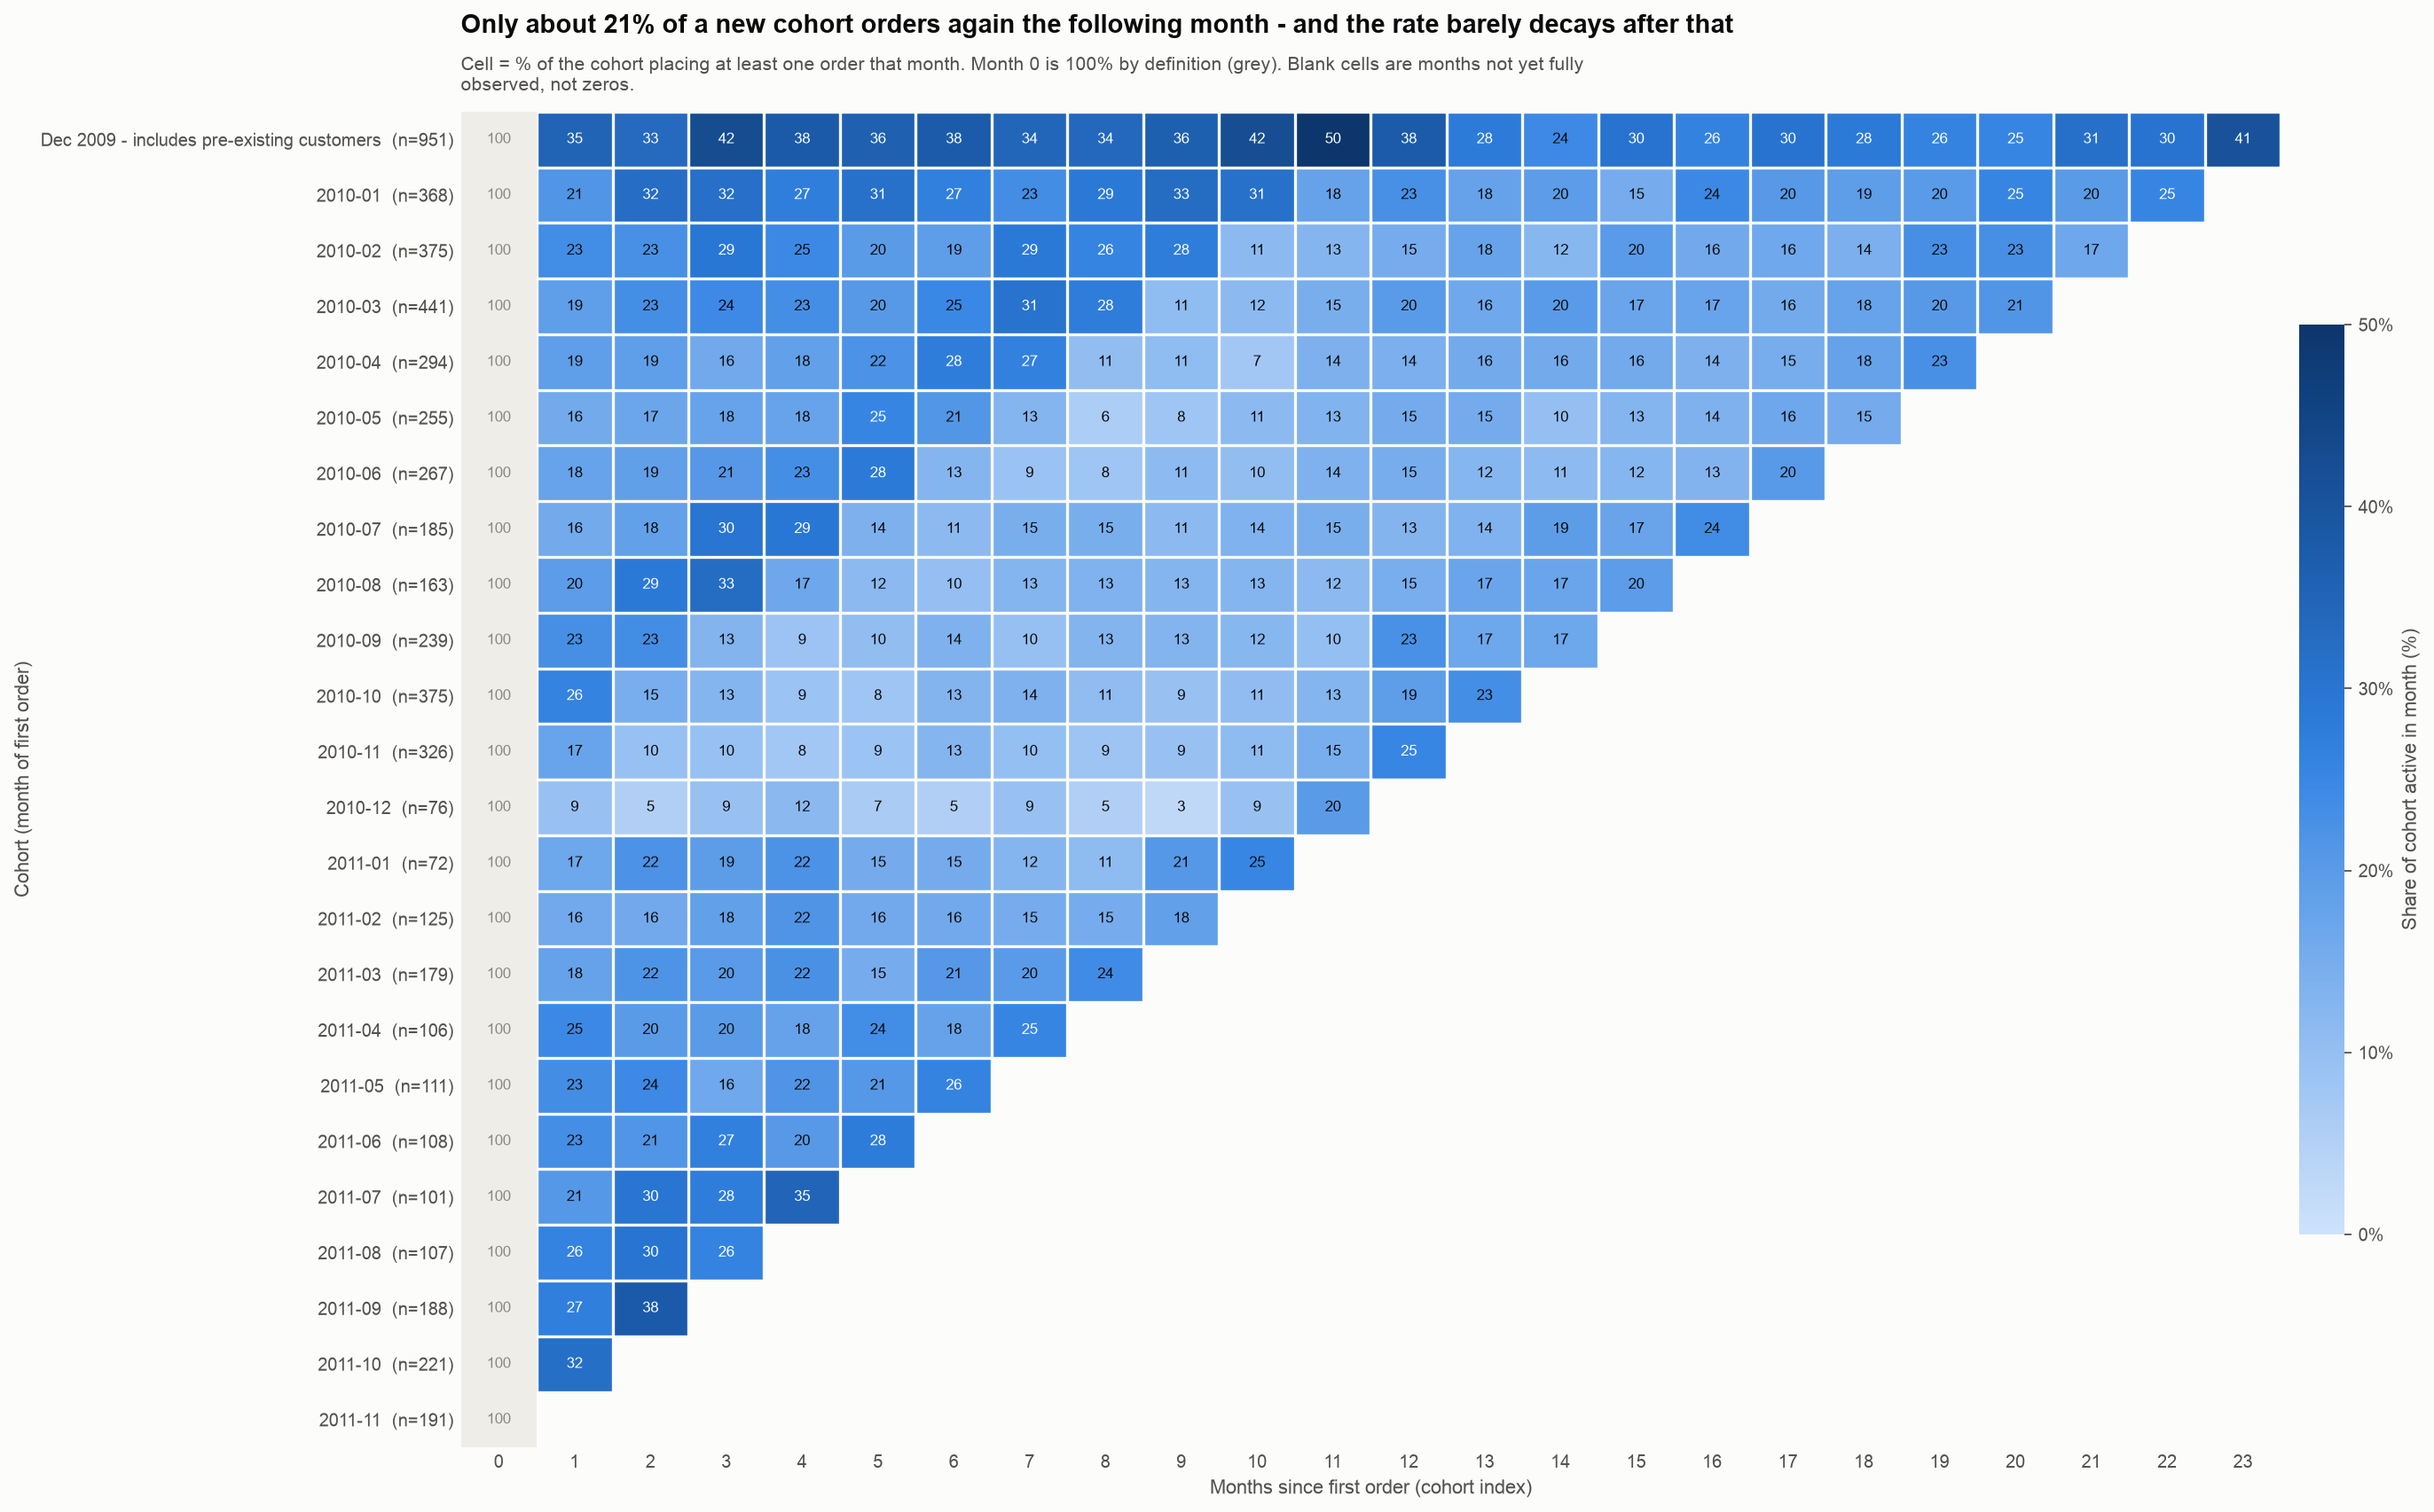

In [5]:
plots.retention_heatmap(pct, sizes, bounds["first_month"])

In [6]:
first, last = pct.index[0], pct.index[-1]
true_new = pct.loc[pct.index > bounds["first_month"]]
display(Markdown(
    f"**How to read it.** Each row is a cohort, each column a month since the first order. The top row "
    f"({first}) is not a real cohort: the data starts that month, so its {int(sizes[first]):,} 'new' customers "
    f"include long-standing ones, and it retains {pct.loc[first, 1]:.0%} in month 1 against "
    f"{true_new[1].mean():.0%} on average for true-new cohorts. It is shown for context and excluded from every "
    f"average below. Blank cells are months that have not been fully observed - the data ends "
    f"{bounds['data_end']:%d %b %Y}, so {bounds['last_month']} is partial and masked."))

**How to read it.** Each row is a cohort, each column a month since the first order. The top row (2009-12) is not a real cohort: the data starts that month, so its 951 'new' customers include long-standing ones, and it retains 35% in month 1 against 21% on average for true-new cohorts. It is shown for context and excluded from every average below. Blank cells are months that have not been fully observed - the data ends 09 Dec 2011, so 2011-12 is partial and masked.

## 3. Retention curves for selected cohorts

The cohorts are picked by rule, not by eye: the earliest true-new cohort, one six months later, the first Q4 cohort, the largest fully observed cohort of the final year, and the latest fully observed cohort.

selected cohorts: ['2010-01', '2010-06', '2010-10', '2011-03', '2011-08']


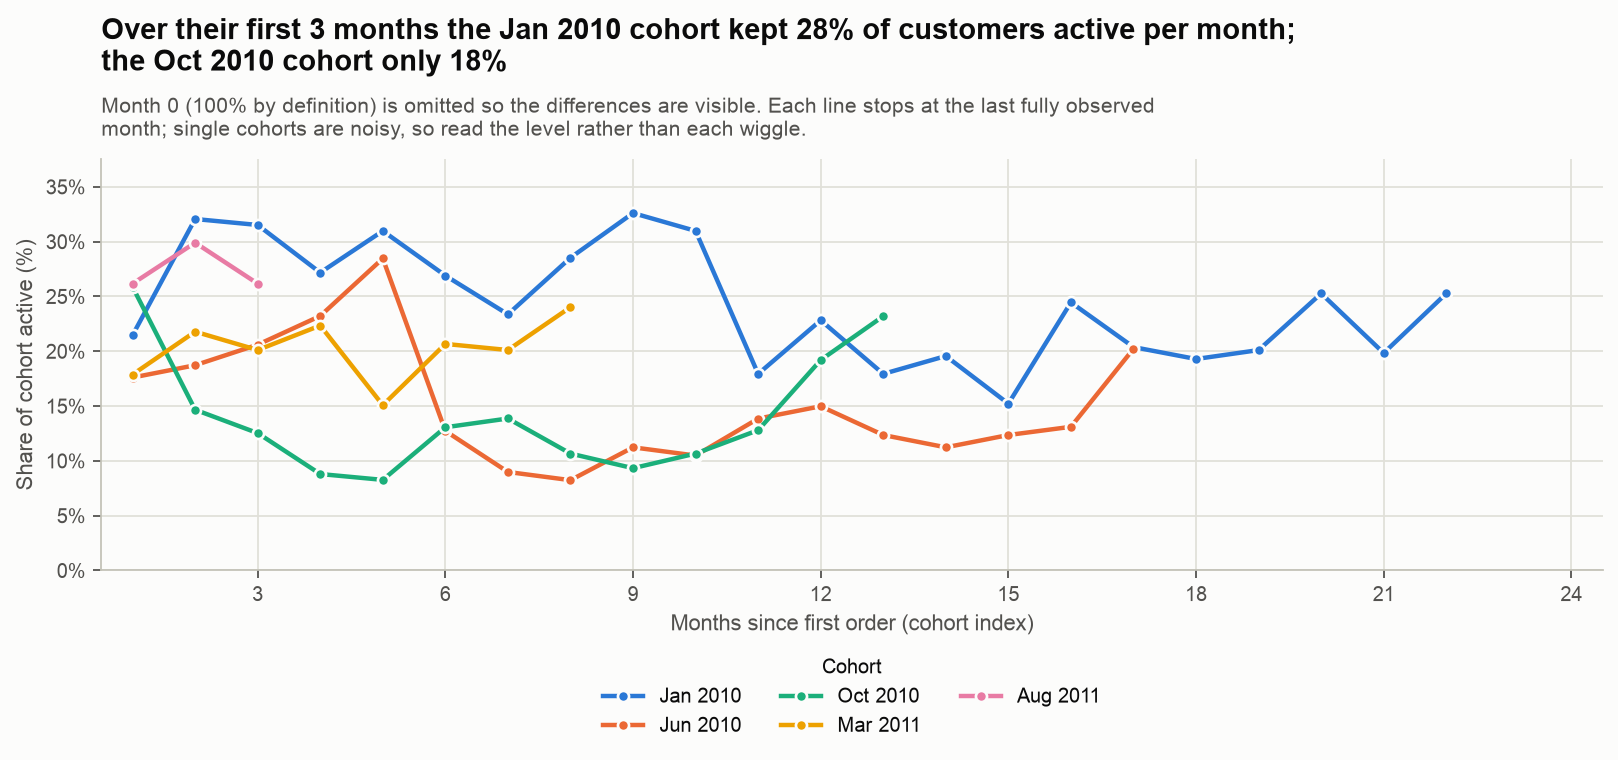

In [7]:
summary = core.cohort_summary(customers, bounds, WINDOW)
selected = core.select_cohorts(summary, bounds, WINDOW)
print("selected cohorts:", [str(c) for c in selected])
plots.retention_curves(pct, selected, bounds["first_month"])

## 4. Average retention curve and the biggest drop-off

Averaged over **true-new cohorts only**, and month N uses only cohorts that have fully observed month N (at least three of them), so old cohorts alone cannot drag the curve up.

In [8]:
avg = core.average_retention_table(pct, first_month=bounds["first_month"])
dropoff = core.dropoff_table(avg["mean_retention"]).join(avg["n_cohorts"])
dropoff.style.format({"Retention": "{:.1%}", "Change": "{:+.1%}", "PctOfPrevious": "{:.1%}"}, na_rep="-")

,Retention,Change,PctOfPrevious,n_cohorts
month_index,,,,
0,100.0%,-,-,23
1,20.7%,-79.3%,20.7%,22
2,21.7%,+1.0%,104.9%,21
3,21.0%,-0.7%,97.0%,20
4,19.9%,-1.2%,94.5%,19
5,18.1%,-1.8%,91.0%,18
6,17.3%,-0.8%,95.8%,17
7,17.2%,-0.2%,99.0%,16
8,14.8%,-2.3%,86.4%,15


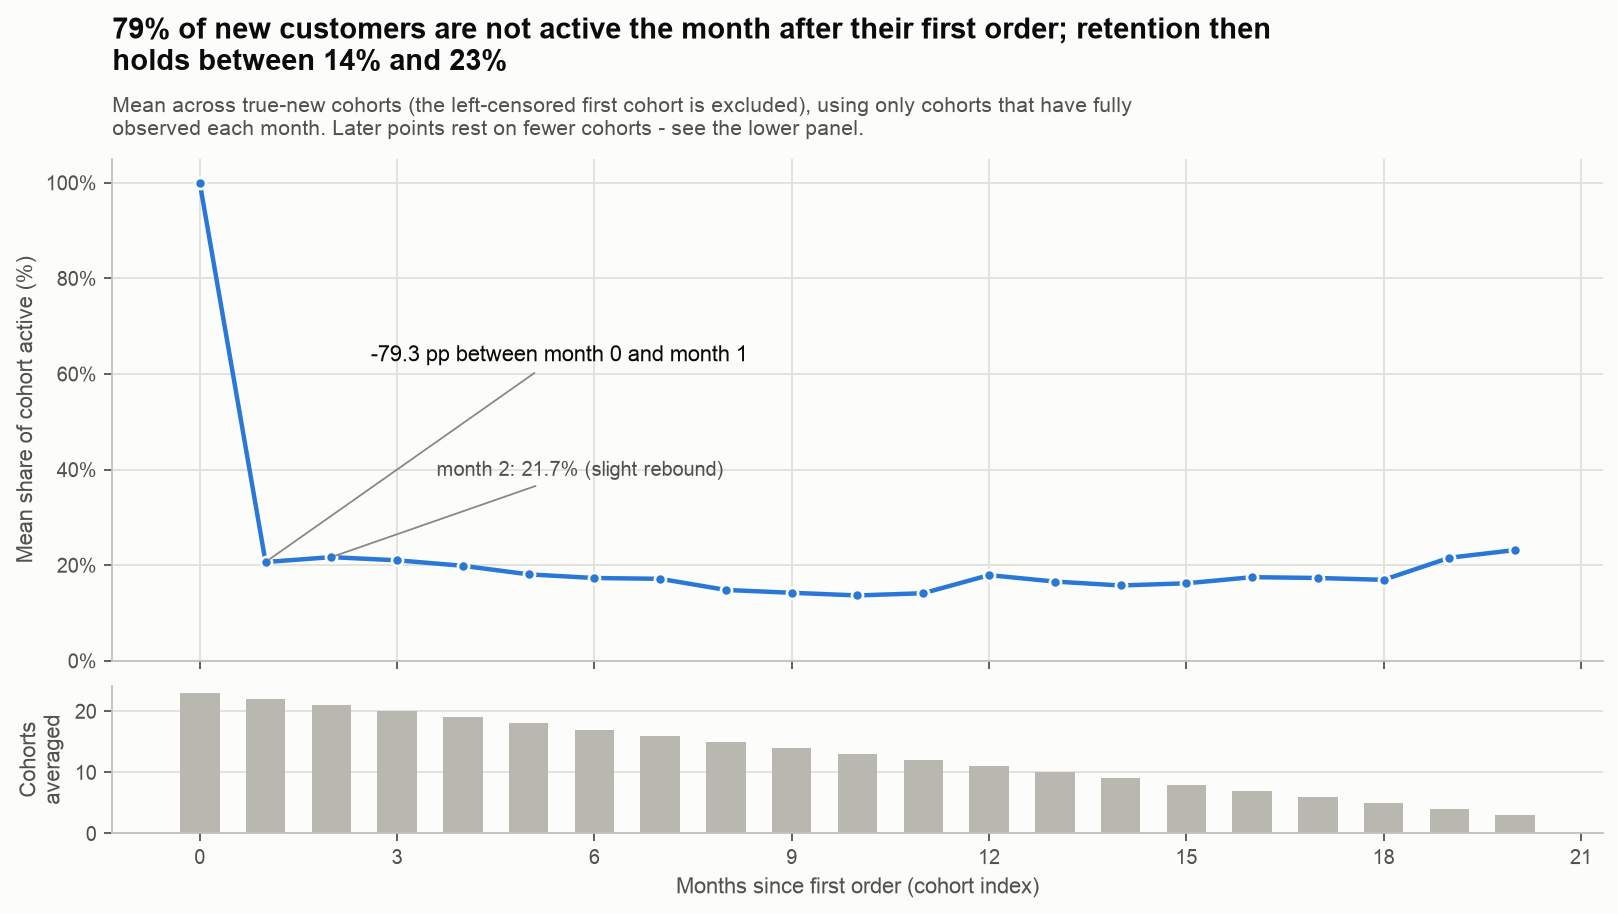

In [9]:
plots.avg_retention_curve(avg)

In [10]:
worst = int(dropoff["Change"].idxmin())
later = avg.loc[avg.index >= 1, "mean_retention"]
display(Markdown(
    f"**Where is the biggest drop-off?** Between month {worst - 1} and month {worst}: average retention falls "
    f"**{abs(dropoff.loc[worst, 'Change']) * 100:.1f} percentage points**, from 100% to "
    f"**{avg.loc[1, 'mean_retention']:.1%}**. Nothing afterwards comes close - the next-largest monthly fall is "
    f"{abs(dropoff['Change'].drop(worst).min()) * 100:.1f} pp.\n\n"
    f"Month 2 is **{avg.loc[2, 'mean_retention']:.1%}**, slightly *above* month 1 - a small rebound that is left "
    f"as it is rather than smoothed away (plausibly customers on a longer re-order cycle; the data cannot say). "
    f"After that the share of a cohort active each month stays between {later.min():.1%} and "
    f"{later.max():.1%}. The lifecycle problem is the first 30 days, not slow decay later.\n\n"
    f"**Do newer cohorts retain better or worse?** Month-1 retention is "
    f"{pct.loc[[c for c in pct.index if c.year == pct.index[1].year and c > bounds['first_month']], 1].mean():.1%} "
    f"on average for {pct.index[1].year} cohorts and "
    f"{pct.loc[[c for c in pct.index if c.year == pct.index[-1].year], 1].mean():.1%} for {pct.index[-1].year} "
    f"cohorts with month 1 observed - see notebook 03 for the like-for-like comparison."))

**Where is the biggest drop-off?** Between month 0 and month 1: average retention falls **79.3 percentage points**, from 100% to **20.7%**. Nothing afterwards comes close - the next-largest monthly fall is 2.3 pp.

Month 2 is **21.7%**, slightly *above* month 1 - a small rebound that is left as it is rather than smoothed away (plausibly customers on a longer re-order cycle; the data cannot say). After that the share of a cohort active each month stays between 13.7% and 23.2%. The lifecycle problem is the first 30 days, not slow decay later.

**Do newer cohorts retain better or worse?** Month-1 retention is 18.9% on average for 2010 cohorts and 22.7% for 2011 cohorts with month 1 observed - see notebook 03 for the like-for-like comparison.